In [ ]:
import os

import psycopg
import pandas as pd
import mlflow
from catboost import CatBoostClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import psycopg
from sklearn.model_selection import train_test_split

load_dotenv("/home/mle-user/mle_projects/mle-mlflow/.env")

TABLE_NAME = "users_churn" # таблица с данными в postgres 

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ['AWS_ACCESS_KEY_ID'] = os.getenv('S3_ACCESS_KEY')
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("S3_SECRET_KEY")

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

EXPERIMENT_NAME = "churn_prediction"
RUN_NAME = "choose_fitch_V3" 
REGISTRY_MODEL_NAME = "churn_model_georgioparin"
FS_ASSETS = "fs_assets"

/home/mle-user/.local/lib/python3.10/site-packages/pydantic/_internal/_fields.py:151: UserWarning: Field "model_server_url" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/mle-user/.local/lib/python3.10/site-packages/pydantic/_internal/_config.py:322: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


In [2]:
connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

with psycopg.connect(**connection) as conn:

    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df.head(2)

NameError: name 'TABLE_NAME' is not defined

In [ ]:
X = df.drop(columns=['id', "customer_id", 'begin_date', 'end_date', 'target'])
y = df['target']

X = pd.get_dummies(X, drop_first=True, dtype=int)
X = X.fillna(X.median())

# НЕ делаем X = X.values — оставляем DataFrame

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train_features, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42)

In [ ]:
estimator = RandomForestClassifier(n_estimators=100)

sfs = SFS(estimator,
    k_features=10,       
    forward=True,      
    floating=False,     
    scoring='roc_auc', 
    cv=4,               
    n_jobs=-1
)

sbs = SFS(estimator,
    k_features=10,       
    forward=False,      
    floating=False,     
    scoring='roc_auc', 
    cv=4,               
    n_jobs=-1
)

sfs = sfs.fit(X_train_features, y_train)
sbs = sbs.fit(X_train_features, y_train)

top_sfs = sfs.k_feature_names_
top_sbs = sbs.k_feature_names_

print('\nSequential Forward Selection (k=10)')
print('CV Score:')
print(sfs.k_score_)

print('\nSequential Backward Selection')
print('CV Score:')
print(sbs.k_score_)


Sequential Forward Selection (k=10)
CV Score:
0.7946243079307475

Sequential Backward Selection
CV Score:
0.8239586542684443


In [ ]:
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T

os.mkdir(FS_ASSETS)

sfs_df.to_csv(f"{FS_ASSETS}/sfs.csv")
sbs_df.to_csv(f"{FS_ASSETS}/sbs.csv")

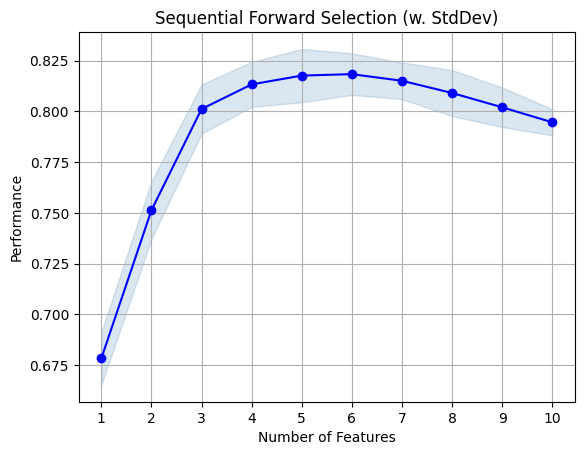

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig("fs_assets/sfs.png")

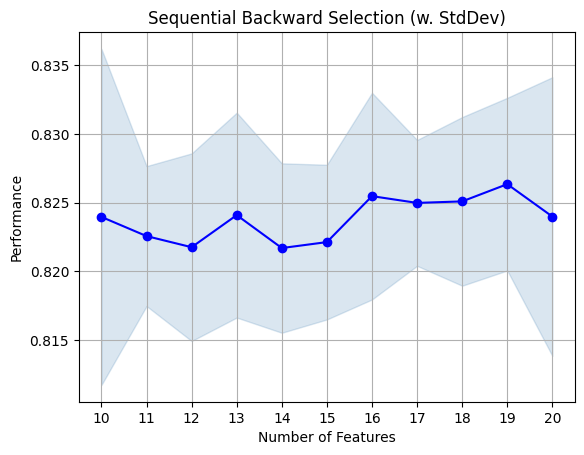

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sbs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig("fs_assets/sbs.png")

In [ ]:
interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))

In [ ]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=f"{RUN_NAME}_intersection_and_union", experiment_id=experiment_id) as run:
    run_id = run.info.run_id
   
    mlflow.log_artifacts(FS_ASSETS)

In [ ]:
run_id

'f9b4c556e2304e21960a98a319d13815'

In [ ]:
interc_features

['paperless_billing_Yes', 'type_Two year', 'type_One year', 'tech_support_Yes']

In [ ]:
union_features

['payment_method_Electronic check',
 'payment_method_Mailed check',
 'total_charges',
 'tech_support_Yes',
 'streaming_movies_Yes',
 'type_One year',
 'type_Two year',
 'payment_method_Credit card (automatic)',
 'multiple_lines_Yes',
 'paperless_billing_Yes',
 'device_protection_Yes',
 'streaming_tv_Yes',
 'monthly_charges',
 'gender_Male',
 'senior_citizen',
 'internet_service_Fiber optic']

In [ ]:
X_train_full

,monthly_charges,total_charges,senior_citizen,type_One year,type_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,online_security_Yes,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,gender_Male,partner_Yes,dependents_Yes,multiple_lines_Yes
2142,70.00,740.00,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0
1623,74.60,548.90,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1
6074,19.85,64.55,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
1362,92.55,4039.00,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,1,1,1
6754,29.70,438.25,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,30.75,1489.30,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0
5191,96.25,4990.25,0,0,1,1,0,0,0,1,0,0,1,1,0,1,1,1,1,1
5226,86.45,5762.95,0,1,0,0,1,0,0,1,0,1,1,0,0,0,0,1,0,1
5390,100.90,5552.05,0,1,0,1,0,0,1,1,1,1,0,0,1,1,1,0,0,0


In [ ]:
X_train_features_intersec = X_train_features[interc_features]
X_test_intersec = X_test[interc_features]

from sklearn.metrics import roc_auc_score, precision_score, recall_score

model = CatBoostClassifier(iterations=150, verbose=0)
model.fit(X_train_features_intersec, y_train)

prediction = model.predict(X_test_intersec)
probas = model.predict_proba(X_test_intersec)[:, 1]

metrics = {
    "auc": roc_auc_score(y_test, probas),
    "precision": precision_score(y_test, prediction),
    "recall": recall_score(y_test, prediction)
}

print(metrics)

pip_requirements = "/home/mle-user/mle_projects/mle-mlflow/requirements.txt"
signature = mlflow.models.infer_signature(X_test_intersec, prediction)
input_example = X_test_intersec[:10]
metadata = {'model_type': 'monthly'}

EXPERIMENT_NAME = "feature_selection_intersection"
RUN_NAME = "version_1"
REGISTRY_MODEL_NAME = "churn_model_catboost_fitch"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    mlflow.log_metrics(metrics)

    model_info = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="models",
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        registered_model_name=REGISTRY_MODEL_NAME,
        await_registration_for=60
    )

{'auc': 0.7770985615066461, 'precision': 0.48654708520179374, 'recall': 0.5864864864864865}


/home/mle-user/.local/lib/python3.10/site-packages/mlflow/models/signature.py:212: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input) if model_input is not None else None
/home/mle-user/.local/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replac

In [ ]:
X_train_features_union = X_train_features[union_features]
X_test_union = X_test[union_features]

from sklearn.metrics import roc_auc_score, precision_score, recall_score

model = CatBoostClassifier(iterations=150, verbose=0)
model.fit(X_train_features_union, y_train)

prediction = model.predict(X_test_union)
probas = model.predict_proba(X_test_union)[:, 1]

metrics = {
    "auc": roc_auc_score(y_test, probas),
    "precision": precision_score(y_test, prediction),
    "recall": recall_score(y_test, prediction)
}

print(metrics)

pip_requirements = "/home/mle-user/mle_projects/mle-mlflow/requirements.txt"
signature = mlflow.models.infer_signature(X_test_union, prediction)
input_example = X_test_union[:10]
metadata = {'model_type': 'monthly'}

EXPERIMENT_NAME = "feature_selection_union"
RUN_NAME = "version_1"
REGISTRY_MODEL_NAME = "churn_model_catboost_fitch"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    mlflow.log_metrics(metrics)

    model_info = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="models",
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        registered_model_name=REGISTRY_MODEL_NAME,
        await_registration_for=60
    )

{'auc': 0.8425487084774863, 'precision': 0.6444444444444445, 'recall': 0.5486486486486486}


/home/mle-user/.local/lib/python3.10/site-packages/mlflow/models/signature.py:212: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input) if model_input is not None else None
/home/mle-user/.local/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replac

In [ ]:
client = mlflow.tracking.MlflowClient()

for name in ["model_registred_name_interc", "model_registred_name_union"]:
    for v in client.search_model_versions(f"name='{name}'"):
        run = client.get_run(v.run_id)
        print(f"name={name} | version={v.version} | run_name={run.info.run_name} | run_id={v.run_id}")

name=model_registred_name_interc | version=1 | run_name=version_1 | run_id=5f7ba632d0a3401eb198913a1793a033
name=model_registred_name_union | version=1 | run_name=version_2 | run_id=f6d7d70c4d314cf5a912f763c4bf5dfa


In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score

X_train_features_intersec = X_train_features[interc_features]
X_test_intersec = X_test[interc_features]

model = CatBoostClassifier(iterations=150, verbose=0)
model.fit(X_train_features_intersec, y_train)

prediction = model.predict(X_test_intersec)
probas = model.predict_proba(X_test_intersec)[:, 1]

metrics = {
    "auc": roc_auc_score(y_test, probas),
    "precision": precision_score(y_test, prediction),
    "recall": recall_score(y_test, prediction),
}
print("intersection:", metrics)

pip_requirements = "/home/mle-user/mle_projects/mle-mlflow/requirements.txt"
signature = mlflow.models.infer_signature(X_test_intersec, prediction)
input_example = X_test_intersec[:10]
metadata = {'model_type': 'monthly'}

EXPERIMENT_NAME = "feature_selection_intersection"
RUN_NAME = "version_1"
REGISTRY_MODEL_NAME = "churn_model_catboost_fitch"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
experiment_id = experiment.experiment_id if experiment else mlflow.create_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id_interc = run.info.run_id
    mlflow.log_metrics(metrics)
    model_info_interc = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="models",
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        registered_model_name=REGISTRY_MODEL_NAME,
        await_registration_for=60,
    )

print("run_id_interc:", run_id_interc)
print("model_version_interc:", model_info_interc.registered_model_version)

intersection: {'auc': 0.7770985615066461, 'precision': 0.48654708520179374, 'recall': 0.5864864864864865}


/home/mle-user/.local/lib/python3.10/site-packages/mlflow/models/signature.py:212: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input) if model_input is not None else None
/home/mle-user/.local/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replac

run_id_interc: 7a98ca7c6bcc4d8b93f171f1de3c715b


Created version '3' of model 'churn_model_catboost_fitch'.


AttributeError: 'ModelInfo' object has no attribute 'registered_model_version'

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score

X_train_features_union = X_train_features[union_features]
X_test_union = X_test[union_features]

model = CatBoostClassifier(iterations=150, verbose=0)
model.fit(X_train_features_union, y_train)

prediction = model.predict(X_test_union)
probas = model.predict_proba(X_test_union)[:, 1]

metrics = {
    "auc": roc_auc_score(y_test, probas),
    "precision": precision_score(y_test, prediction),
    "recall": recall_score(y_test, prediction),
}
print("union:", metrics)

pip_requirements = "/home/mle-user/mle_projects/mle-mlflow/requirements.txt"
signature = mlflow.models.infer_signature(X_test_union, prediction)
input_example = X_test_union[:10]
metadata = {'model_type': 'monthly'}

EXPERIMENT_NAME = "feature_selection_union"
RUN_NAME = "version_2"
REGISTRY_MODEL_NAME = "churn_model_catboost_fitch"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
experiment_id = experiment.experiment_id if experiment else mlflow.create_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id_union = run.info.run_id
    mlflow.log_metrics(metrics)
    model_info_union = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="models",
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        registered_model_name=REGISTRY_MODEL_NAME,
        await_registration_for=60,
    )

print("run_id_union:", run_id_union)
print("model_version_union:", model_info_union.registered_model_version)

union: {'auc': 0.8425487084774863, 'precision': 0.6444444444444445, 'recall': 0.5486486486486486}


/home/mle-user/.local/lib/python3.10/site-packages/mlflow/models/signature.py:212: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input) if model_input is not None else None
/home/mle-user/.local/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replac

run_id_union: 01cdb3d20f074fb59dc0094655cc93f0


Created version '4' of model 'churn_model_catboost_fitch'.


AttributeError: 'ModelInfo' object has no attribute 'registered_model_version'

In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
registred_model_name = "churn_model_catboost_fitch"

# собираем все версии модели и мапим run_id -> version
versions = client.search_model_versions(f"name='{registred_model_name}'")
runid_to_version = {v.run_id: int(v.version) for v in versions}

model_version_id_interc = runid_to_version[run_id_interc]
model_version_id_union = runid_to_version[run_id_union]

# имена run'ов (то, что в отчёте названо model_registred_name_*)
model_registred_name_interc = client.get_run(run_id_interc).data.tags.get("mlflow.runName")
model_registred_name_union = client.get_run(run_id_union).data.tags.get("mlflow.runName")

run_name_interc = "feature_selection_intersection"  # название эксперимента
run_name_union = "feature_selection_union"          # название эксперимента

print("registred_model_name        =", repr(registred_model_name))
print()
print("model_registred_name_interc =", repr(model_registred_name_interc))
print("model_version_id_interc     =", model_version_id_interc)
print("run_name_interc             =", repr(run_name_interc))
print("run_id_interc               =", repr(run_id_interc))
print()
print("model_registred_name_union  =", repr(model_registred_name_union))
print("model_version_id_union      =", model_version_id_union)
print("run_name_union              =", repr(run_name_union))
print("run_id_union                =", repr(run_id_union))

registred_model_name        = 'churn_model_catboost_fitch'

model_registred_name_interc = 'version_1'
model_version_id_interc     = 3
run_name_interc             = 'feature_selection_intersection'
run_id_interc               = '7a98ca7c6bcc4d8b93f171f1de3c715b'

model_registred_name_union  = 'version_2'
model_version_id_union      = 4
run_name_union              = 'feature_selection_union'
run_id_union                = '01cdb3d20f074fb59dc0094655cc93f0'
